<a href="https://colab.research.google.com/github/Imesh-Isuranga/ME-422-Group-B1/blob/main/Controls/E20128.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Instructions

* Complete the activities in groups that were assigned for ME421 for the vibrations lab.

* Make a copy of this and save it in your group github group repository with your index number as the file name

* Do all your work, EXCLUSIVELY, in that saved notebook. Your github commits will serve as a refelection of your individual contributions.

#References

* https://github.com/mugalan/intrinsic-rigid-body-control-estimation/tree/main/rigid-body-control

#Task#1

## Twin rotor system dynamic model

Image Credits: Bhashitha Maduranga Nawaratne bhashitha614@gmail.com

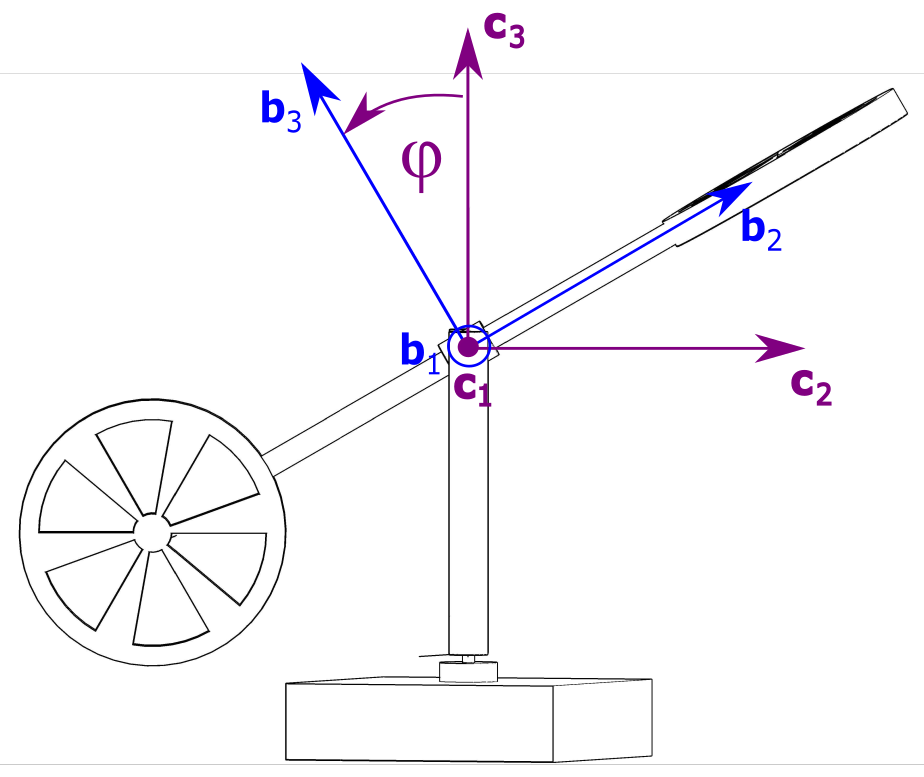

Show that the twin rotor system shown above can be modelled by

\begin{align}
\dot{R}&=\widehat{\omega}R,\\
\dot{\pi}&=\tau^e+\tau^u,
\end{align}
where
\begin{align}
\omega &=(\mathbb{I}^R)^{-1}\pi,
\end{align}
Here we have split the force and control moments into unmanipulatable and manipulatable (control) part. The manipulatable (control) part will be denoted by a superscript $u$ and takes the form

\begin{align*}
\tau^u &=R\begin{bmatrix}
1 & 0\\
0 & 0\\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos{\alpha} & -\cos{\beta}\\
\sin{\alpha} & -\sin{\beta}
\end{bmatrix}
\begin{bmatrix}
u_1\\ u_2
\end{bmatrix}
\end{align*}
and the constriant moment that prevents the rotation of the device about $\mathbb{b}_2$ axis is
\begin{align}
\tau^e=R\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
\end{align}
with $T_2$ given by
\begin{align}
T_2&=e_2^T \left(\Omega \times \mathbb{I}\Omega+\mathbb{I}\dot{\Omega}
\right)
\end{align}
where $\Omega = R^T\omega$.

# Task#2

Simulate and animate the motion of the system for various different realistic inputs. For examle a vertical axis spin and a horizontal axis swing up and down motion

#Task#3

Let $R_r(t)$ be a desired trajectory and $\omega_r(t)$ be such that $\widehat{\omega}_r(t)=\dot{R}_rR_r^T$. In line with the system define the reference spatial angular momentum $\pi_r\triangleq R_r\mathbb{I}R_r^T\omega_r$

Define the configurarion error
\begin{align}
R_e&=R_rR^T.
\end{align}
Then the spatial angular velcity of the tracking error is defined by
\begin{align}
\widehat{\omega}_e&\triangleq \dot{R}_eR_e^T=\widehat{\omega}_r(t)-R_e\widehat{\omega}(t)R_e^T
\end{align}
and hence that
\begin{align}
\omega_e&=\omega_r-R_e\omega.
\end{align}
Define the angular momentum error as
\begin{align}
\pi_e\triangleq R\mathbb{I}R_r^T\omega_e=R\mathbb{I}R_r^T(\omega_r-R_e\omega)=R\mathbb{I}R_r^T\omega_r-R\mathbb{I}R^T\omega=R_e^T\pi_r-\pi.
\end{align}


Differentiating $\pi_e$ we have
\begin{align}
\dot{\pi}_e&=R_e^T(\dot{\pi}_r-\omega_e\times \pi_r)-\dot{\pi}=R_e^T(R_r\dot{\Pi}_r+(\omega_r-\omega_e)\times \pi_r)-\dot{\pi}=(R\dot{\Pi}_r+\omega\times \pi_r)-\dot{\pi}
\end{align}



Thus we have the error dynamics
\begin{align}
\dot{R}_e&=\widehat{\omega}_eR_e,\\
\dot{\pi}_e&=(R\dot{\Pi}_r+\omega\times \pi_r)-\tau_u-\tau_e
\end{align}

**Using these error dynamics derive a PID controller for the tracking problem and simulate its performance.**

#Task#4

 Experimentally verify the stability properties of the controller derived in Task#3 using the experimental setup available in the applied mechanics lab.

Here are few example our own implementations of this controller on UAVs

* https://youtu.be/6E9WDQNVSYA
* https://youtu.be/uUKxXImRMOA
* https://youtu.be/zq05N8m_9SA
* https://youtu.be/J5dThZGZN2g
* https://youtu.be/J5MMp6Be3tU
* https://youtu.be/6ZQgE1FI6Wc

TASK 01


Building Libraries

In [2]:
import numpy as np
import scipy as sp
from scipy.integrate import odeint
import math
from numpy import linalg
import sympy
from sympy import symbols
from sympy import *

import plotly.graph_objects as go
import plotly.express as px
from sympy.physics.mechanics import dynamicsymbols, init_vprinting
from IPython.display import display, Math, Latex

In [3]:
from sympy import symbols
from sympy.physics.mechanics import dynamicsymbols, init_vprinting

# Time-dependent variables
alpha, theta, phi, gamma, R, Omega, I = dynamicsymbols('alpha theta phi gamma R Omega I')

# Independent time variable and constants
t, I_1, I_2, I_3, l = symbols('t I_1 I_2 I_3 l')

# Pretty printing
init_vprinting()

In [4]:
dtheta = theta.diff(t);  ddtheta = dtheta.diff(t)
dalpha = alpha.diff(t);  ddalpha = dalpha.diff(t)
dgamma = gamma.diff(t);  dgamma  = dgamma.diff(t)
dphi   = phi.diff(t);    ddphi   = dphi.diff(t)

In [5]:
R1_phi = Matrix([[1, 0, 0],
                 [0, cos(phi), -sin(phi)],
                 [0, sin(phi),  cos(phi)]])

R3_alpha = Matrix([[cos(alpha), -sin(alpha), 0],
                   [sin(alpha),  cos(alpha), 0],
                   [0, 0, 1]])

R1_gamma = Matrix([[1, 0, 0],
                   [0, cos(gamma), -sin(gamma)],
                   [0, sin(gamma),  cos(gamma)]])

R3_theta = Matrix([[cos(theta), -sin(theta), 0],
                   [sin(theta),  cos(theta), 0],
                   [0, 0, 1]])

In [6]:
R1_phi

⎡1    0        0   ⎤
⎢                  ⎥
⎢0  cos(φ)  -sin(φ)⎥
⎢                  ⎥
⎣0  sin(φ)  cos(φ) ⎦

In [7]:
R3_alpha

⎡cos(α)  -sin(α)  0⎤
⎢                  ⎥
⎢sin(α)  cos(α)   0⎥
⎢                  ⎥
⎣  0        0     1⎦

In [8]:
R1_gamma

⎡1    0        0   ⎤
⎢                  ⎥
⎢0  cos(γ)  -sin(γ)⎥
⎢                  ⎥
⎣0  sin(γ)  cos(γ) ⎦

In [9]:
R3_theta

⎡cos(θ)  -sin(θ)  0⎤
⎢                  ⎥
⎢sin(θ)  cos(θ)   0⎥
⎢                  ⎥
⎣  0        0     1⎦

In [10]:
II = Matrix([[I_1, 0, 0],
             [0, I_2, 0],
             [0, 0, I_3]])  #the inertia matrix (moment of inertia tensor) of a rigid body in its principal axes frame.

In [12]:
II

⎡I₁  0   0 ⎤
⎢          ⎥
⎢0   I₂  0 ⎥
⎢          ⎥
⎣0   0   I₃⎦

In [13]:
dphi

φ̇

Let us take inertial frame as $\mathbf{e}$, which is fixed to body part E. And $\mathbf{O}$ as the original of the $\mathbf{e}$-frame. Let $\mathbf{c}$ be another orthongonal frame such that it moves with respect to $\mathbf{e}$ in such a way that $\mathbf{c}_3\equiv \mathbf{e}_3$ (Their z-axes are the same) and $\mathbf{c}$-frame is always fixed to body part c. Therefore

\begin{align*}
\mathbf{c}=\mathbf{e}\,R_3(\theta)
\end{align*}

\begin{align*}
R_3(\theta)=\begin{bmatrix}
\cos{\theta}&-\sin{\theta}&0\\
\sin{\theta}&\cos{\theta}&0\\
0&0&1
\end{bmatrix}.
\end{align*} This is a yaw-type rotation.

Let $\mathbf{b}$ be another orthonomal frame such that it moves with respect to $\mathbf{c}$ in such a way that $\mathbf{b}_1\equiv \mathbf{c}_1$(Their x-axes coincide) and $\mathbf{b}$ is always fixed to body part $\mathbf{B}$.

\begin{align*}
\mathbf{b}=\mathbf{c}\,R_1(\phi)
\end{align*}

\begin{align*}
R_1(\phi)=\begin{bmatrix}
1&0&0\\
0&\cos{\phi}&-\sin{\phi}\\
0&\sin{\phi}&\cos{\phi}
\end{bmatrix}.
\end{align*} This is a roll-type rotation.

So,

\begin{align*}
\mathbf{b}=\mathbf{c}R_1(\phi)=\mathbf{e}R_3(\theta)R_1(\phi)=\mathbf{e}R
\end{align*}

Which gives

\begin{align*}
R=R_3(\theta)R_1(\phi)
\end{align*}

Differentiate the rotation matrix,
\begin{align*}
\dot{R}=\dot{R}_3R_1+R_3\dot{R}_1
\end{align*}

For any rotation matrix
R(t), there exists an angular velocity vector
Ω such that:
\begin{align*}
\dot{R}=\ R\widehat{\Omega}
\end{align*}
where

\begin{align*}
\widehat{\Omega}
\end{align*}
is the skew-symmetric (cross-product) matrix

\begin{align*}
R_3\widehat{\Omega}_3R_1+R_3{R}_1\widehat{\Omega}_1=R\widehat{\Omega}
\end{align*}

\begin{align*}
\widehat{\Omega}=R_1^T\widehat{\Omega}_3R_1+\widehat{\Omega}_1
\end{align*}
Converting from skew-matrix form to vector form:

which gives
\begin{align*}
\Omega&=\dot{\phi}\:e_1+\dot{\theta}\ R_1^T{(\phi)}e_3,\\
&= \begin{bmatrix}
\dot{\phi}\\
\dot{\theta}\sin{(\phi)}\\
\dot{\theta}\cos{(\phi)}
\end{bmatrix}
\end{align*}


The angular momentum in $\mathbf{e}$ is
\begin{align}
\pi&=R\mathbb{I}\Omega
\end{align}

Constrains Moments Along b2 Axis - Because 2 DOF

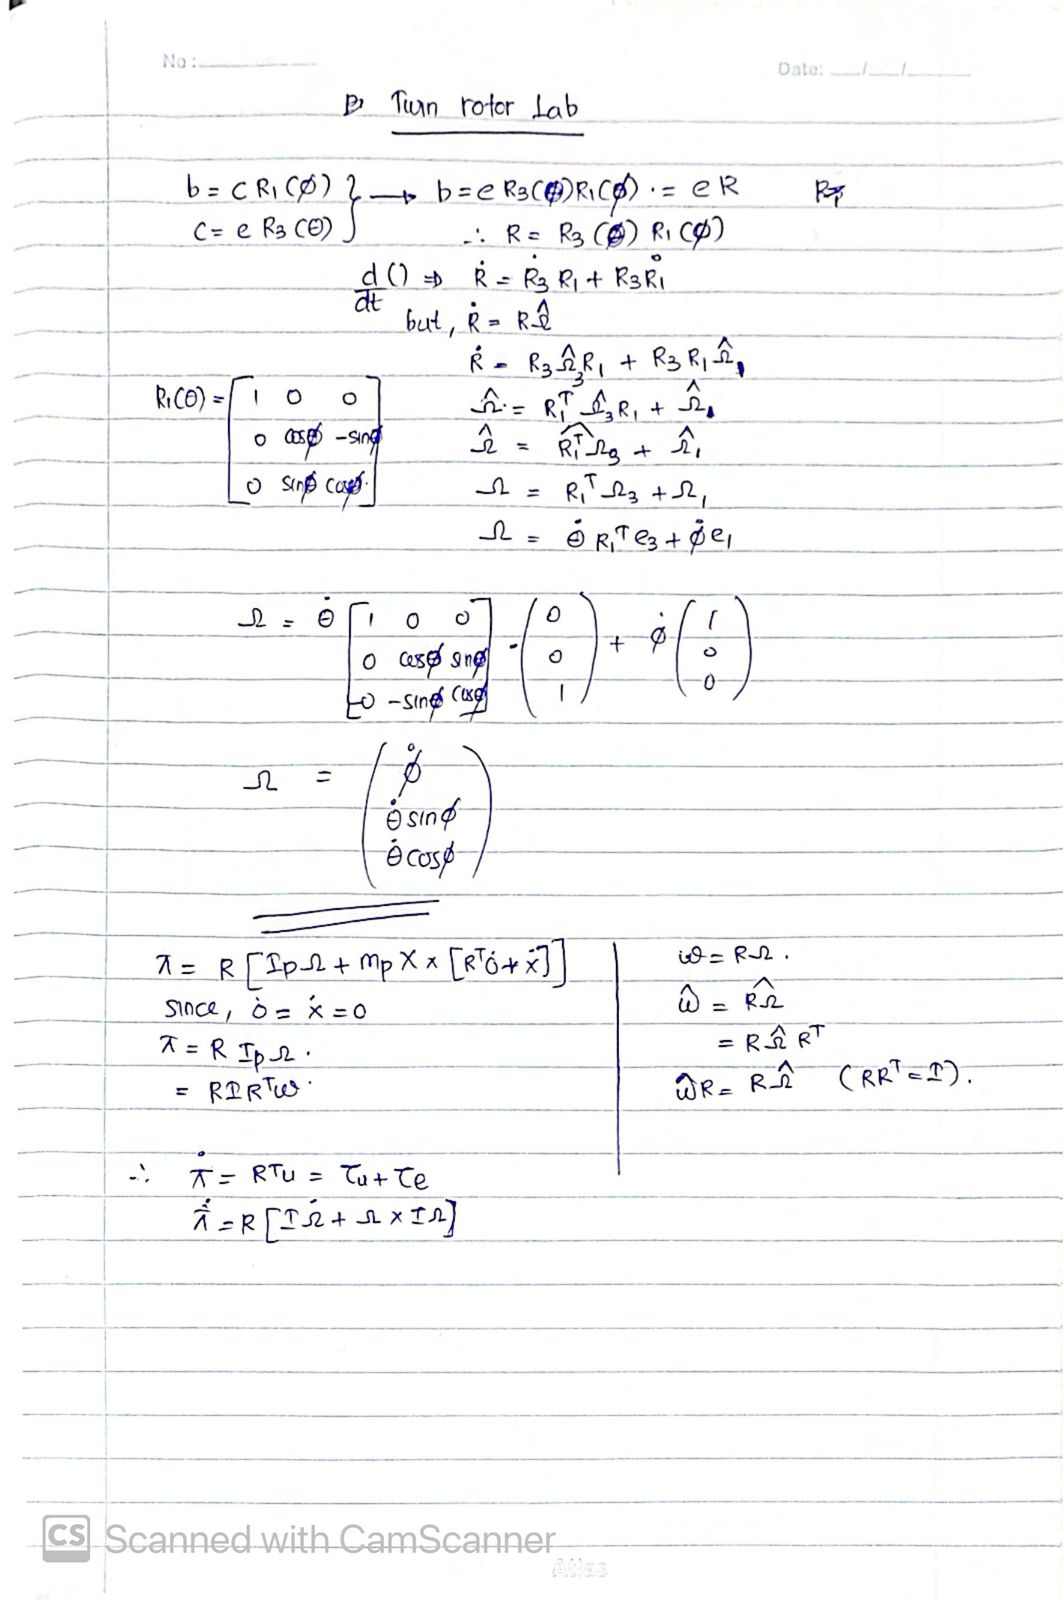

The constraint moment acting on the system prevents a rotation about
b2,which means
Rotation about
b2
is NOT allowed

In the body frame (b-frame), the torque vector is:
\begin{align}
\tau^b=\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
\end{align}
after that,
R converts body-frame vectors to inertial-frame vectors.
\begin{align}
\tau^e=\ R\tau^b
\end{align}

so,
\begin{align}
\tau^e=R\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
\end{align}

# The actuation moments

### Actuation Moments

The torque generated by the two actuators (rotors) is given by

$$
\tau_u = R T_u
$$

where the torque vector in the **body frame** is

$$
T_u =
\begin{bmatrix}
u_1\cos{\alpha} - u_2\cos{\beta} \\
0 \\
u_1\sin{\alpha} - u_2\sin{\beta}
\end{bmatrix}
$$

Therefore, the actuation moment expressed in the inertial frame becomes

$$
\tau_u =
R
\begin{bmatrix}
u_1\cos{\alpha} - u_2\cos{\beta} \\
0 \\
u_1\sin{\alpha} - u_2\sin{\beta}
\end{bmatrix}
$$

Since the system has only **two degrees of freedom**, rotation about the $b_2$ axis is not allowed.  
Therefore, the control torque must satisfy the constraint

$$
T_u^T e_2 = 0
$$

This means that the actuation torque has **no component along the $b_2$ axis**, ensuring that the control inputs are implementable for the constrained system.



The actuation torque generated by the two rotors is

$$
\begin{align*}
\tau_u &= RT_u =
\begin{bmatrix}
u_1\cos{\alpha} - u_2\cos{\beta} \\
0 \\
u_1\sin{\alpha} - u_2\sin{\beta}
\end{bmatrix} \\
&= R
\begin{bmatrix}
1 & 0 \\
0 & 0 \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos{\alpha} & -\cos{\beta} \\
\sin{\alpha} & -\sin{\beta}
\end{bmatrix}
\begin{bmatrix}
u_1 \\
u_2
\end{bmatrix}
\end{align*}
$$

### Equations of Motion

The dynamics of the twin–rotor system can be described using the orientation matrix $R$, the angular velocity $\omega$, and the angular momentum $\pi$.

The **kinematic equation** describing the evolution of the rotation matrix is

$$
\dot{R} = \hat{\omega} R
$$

where $\hat{\omega}$ is the skew–symmetric matrix of the angular velocity vector $\omega$.

The **angular momentum** expressed in the inertial frame is

$$
\pi = R I R^T \omega
$$

where $I$ is the inertia matrix defined in the body frame.

The **equation of motion** for the rigid body is given by

$$
\dot{\pi} = R T_u = \tau_u + \tau_e
$$

where

- $\tau_u$ is the **actuation moment** generated by the rotors  
- $\tau_e$ is the **constraint moment** arising from the mechanical constraint of the system.

---

### Constraint Moment

Since the system has **two degrees of freedom**, rotation about the $b_2$ axis is not allowed.  
Therefore, a **constraint torque** must act along the $b_2$ direction to prevent this rotation.

In the body frame, the constraint torque is

$$
T_e =
\begin{bmatrix}
0 \\
T_2 \\
0
\end{bmatrix}
= e_2 T_2
$$

where

$$
e_2 =
\begin{bmatrix}
0 \\
1 \\
0
\end{bmatrix}
$$

is the unit vector along the $b_2$ axis.

---

### Determination of the Constraint Moment

From the rotational dynamics,

$$
\dot{\pi} = \tau_u + \tau_e
$$

Multiplying both sides by $R^T$ converts the equation to the **body frame**

$$
R^T \dot{\pi} = R^T \tau_u + R^T \tau_e
$$

Since $\tau_e = R e_2 T_2$, we obtain

$$
R^T \tau_e = e_2 T_2
$$

Thus,

$$
R^T \dot{\pi} = R^T \tau_u + e_2 T_2
$$

Taking the projection along $e_2$ gives

$$
T_2 = e_2^T R^T \dot{\pi}
$$

---

### Rigid Body Rotational Dynamics in Body Frame

Define the body angular velocity

$$
\Omega = R^T \omega
$$

The rotational dynamics in body coordinates are given by Euler's equation

$$
R^T \dot{\pi} = I \dot{\Omega} + \Omega \times (I \Omega)
$$

Substituting this into the previous expression for $T_2$ yields

$$
T_2 = e_2^T (\Omega \times I \Omega + I \dot{\Omega})
$$

---

### Final Expression

Therefore, the **constraint moment along the $b_2$ axis** is

$$
T_2 = e_2^T (\Omega \times I \Omega + I \dot{\Omega})
$$

where

$$
\Omega = R^T \omega
$$

represents the angular velocity expressed in the body frame.

# TASK 02


In [14]:
R

R

In [16]:
# Install the simulation helpers
!pip install --quiet "git+https://github.com/mugalan/classical-mechanics-from-a-geometric-point-of-view.git#egg=rigid-body-sim"
import sims
mr = sims.RigidBodySim()

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [17]:
def externalForceModel(qq,parameters,X):
    R=X[0][0];
    M=parameters['M']; g=parameters['g']; CM=parameters['CM'];
    fe=np.array([0,0,0]);
    taue=np.array([0,0,0]);
    return [taue,fe]

def actuator(qq,parameters, t, X, taue,fe):
    R=X[0][0];
    alpha=parameters['alpha']; beta=parameters['beta'];
    u1=0.01; u2=0.01
    tauu=R @ [u1*np.cos(alpha)-u2*np.cos(beta),0,u1*np.sin(alpha)-u2*np.sin(beta)]
    fu=np.array([0,0,0]);
    return [tauu,fu]

mr.set_external_force_model(externalForceModel)
mr.set_actuator(actuator)


In [18]:
cubeDimensions={'l':4,'w':2,'h':1,'xp':2.,'yp':1.,'zp':0.5,};
parameters={'CM':np.array([cubeDimensions['l']/2-cubeDimensions['xp'],cubeDimensions['w']/2-cubeDimensions['yp'],cubeDimensions['h']/2-cubeDimensions['zp']]), 'g':1, 'M':1, 'II':np.array([[1.,0.,0.],[0.,1.,0.],[0.,0.,1.]])};
parameters.update({'alpha':1*np.pi/6,'beta':0*np.pi/6})
ICq=mr.q_from_axis_angles(0.,np.array([1,0,0]));
ICR=mr.r_from_quaternions(ICq);
ICOmega=np.array([0.,0.,0.]); ICo=np.array([0.,0.,0.]); ICp=np.array([0.,0.,0.]);
ICXC=np.array([0,0,0]);
ICs=[[ICR,ICo],ICR@ICOmega,ICp,ICXC]

In [19]:
parameters

{'CM': array([0., 0., 0.]),
 'g': 1,
 'M': 1,
 'II': array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 'alpha': 0.5235987755982988,
 'beta': 0.0}

In [20]:
aa4=mr.simulating_a_cube(0.1, 50., cubeDimensions, parameters,ICs)
fig1=mr.animated_cube_flat_shading(aa4,'Twin rotor as a box')

In [23]:
import numpy as np

# -----------------------------
# External forces: IGNORE gravity
# -----------------------------
def externalForceModel(qq, parameters, X):
    taue = np.array([0.0, 0.0, 0.0])
    fe   = np.array([0.0, 0.0, 0.0])
    return [taue, fe]

# -----------------------------
# Inputs for different motions
# -----------------------------
def control_inputs(t, mode="spin"):
    # Increase these to see motion clearly
    U0   = 0.8     # constant level
    Uamp = 0.8     # sinusoidal amplitude
    f    = 0.5     # Hz
    w    = 2*np.pi*f

    if mode == "spin":
        # Constant torque -> angular speed increases (spin-up)
        u1, u2 = U0, 0.0

    elif mode == "swing":
        # Oscillating torque -> back/forth motion
        u1, u2 = Uamp*np.sin(w*t), 0.0

    elif mode == "mixed":
        # Spin + swing
        u1, u2 = U0 + Uamp*np.sin(w*t), 0.0

    else:
        u1, u2 = 0.0, 0.0

    return u1, u2

# -----------------------------
# Actuator torque model
# -----------------------------
def actuator(qq, parameters, t, X, taue, fe):
    R = X[0][0]
    alpha = parameters['alpha']
    beta  = parameters['beta']
    mode  = parameters.get("mode", "spin")

    u1, u2 = control_inputs(t, mode=mode)

    # Body-frame torque (no b2 component)
    Tu_body = np.array([
        u1*np.cos(alpha) - u2*np.cos(beta),
        0.0,
        u1*np.sin(alpha) - u2*np.sin(beta)
    ], dtype=float)

    # Convert to inertial frame torque (matches your slide form)
    tauu = R @ Tu_body

    fu = np.array([0.0, 0.0, 0.0])
    return [tauu, fu]

# -----------------------------
# Register models
# -----------------------------
mr.set_external_force_model(externalForceModel)
mr.set_actuator(actuator)

# -----------------------------
# Cube + parameters
# -----------------------------
cubeDimensions = {'l':4,'w':2,'h':1,'xp':2.,'yp':1.,'zp':0.5}

parameters_base = {
    'CM': np.array([0.0, 0.0, 0.0]),   # irrelevant since gravity ignored
    'g': 0.0,
    'M': 1.0,
    'II': np.array([[1.,0.,0.],
                    [0.,1.,0.],
                    [0.,0.,1.]]),
    'alpha': np.pi/6,
    'beta' : 0.0
}

# -----------------------------
# Initial conditions
# -----------------------------
ICq = mr.q_from_axis_angles(0.0, np.array([1,0,0]))
ICR = mr.r_from_quaternions(ICq)

# IMPORTANT: if you still see "no motion", give a small initial omega:
ICOmega = np.array([0.0, 0.0, 0.0])  # try [0.0, 0.2, 0.0] or [0.2,0,0] if needed

ICo  = np.array([0.0, 0.0, 0.0])
ICp  = np.array([0.0, 0.0, 0.0])
ICXC = np.array([0.0, 0.0, 0.0])

ICs = [[ICR, ICo], ICR @ ICOmega, ICp, ICXC]

dt = 0.02
T  = 20.0

# -----------------------------
# Case 1: Spin
# -----------------------------
parameters_spin = dict(parameters_base)
parameters_spin["mode"] = "spin"
aa_spin = mr.simulating_a_cube(dt, T, cubeDimensions, parameters_spin, ICs)
mr.animated_cube_flat_shading(aa_spin, "Twin rotor — Spin (no gravity)")

# -----------------------------
# Case 2: Swing
# -----------------------------
parameters_swing = dict(parameters_base)
parameters_swing["mode"] = "swing"
aa_swing = mr.simulating_a_cube(dt, T, cubeDimensions, parameters_swing, ICs)
mr.animated_cube_flat_shading(aa_swing, "Twin rotor — Swing (no gravity)")